In [19]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [20]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    bpb:float
    summary:str
    sr:float
    boundary_percent:float

In [21]:
# ? sending whole state in output will cause an error becuase it thinks that we have done simultaneous operations on the same state which is not the case here. So we need to return only the modified state in each function and then merge them together in the end.

def calculateboundaryPerBall(state:BatsmanState):

    bpb=state['balls']/(state['fours']+state['sixes']) if (state['fours']+state['sixes'])>0 else 0


    return {'bpb':bpb}


def calculateSr(state:BatsmanState):
    sr=(state['runs']/state['balls'])*100 if state['balls']>0 else 0

    return {'sr':sr}

def calculateBoundaryPercent(state:BatsmanState):
    boundary_percent=((state['fours']+state['sixes'])/state['balls'])*100 if state['balls']>0 else 0

    return {'boundary_percent':boundary_percent}

def generateSummary(state:BatsmanState):
    summary=f"Runs: {state['runs']}, Balls: {state['balls']}, Fours: {state['fours']}, Sixes: {state['sixes']}"

    return {'summary':summary}


In [22]:
graph=StateGraph(BatsmanState)

graph.add_node('calculate_bpb',calculateboundaryPerBall)
graph.add_node('calculate_sr',calculateSr)
graph.add_node('calculate_boundary_percent',calculateBoundaryPercent)
graph.add_node('generate_summary',generateSummary)

# ? adding edges
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_boundary_percent')

graph.add_edge('calculate_bpb','generate_summary')
graph.add_edge('calculate_sr','generate_summary')
graph.add_edge('calculate_boundary_percent','generate_summary')

graph.add_edge('generate_summary',END)

workflow=graph.compile()

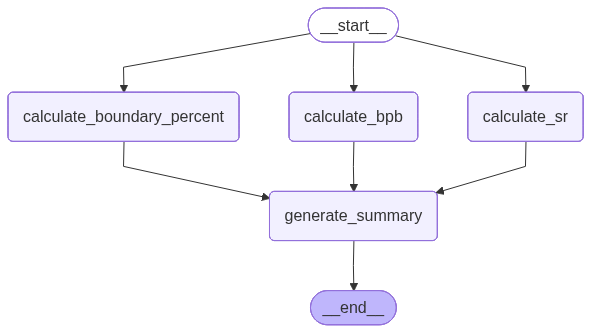

In [23]:
## * code to visualize the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [24]:
initial_state={
    'runs':100,
    'balls':25,
    'fours':8,
    'sixes':10,}

final_state=workflow.invoke(initial_state)

print(final_state)



{'runs': 100, 'balls': 25, 'fours': 8, 'sixes': 10, 'bpb': 1.3888888888888888, 'summary': 'Runs: 100, Balls: 25, Fours: 8, Sixes: 10', 'sr': 400.0, 'boundary_percent': 72.0}
